In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.4 MB/s eta 0:00:00


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
# NOT USED
# improved balanced version: yolov8m + better pedestrian recall + reduced car FP

import os
import glob
import cv2
import pandas as pd
from ultralytics import YOLO
from google.colab import drive

# =========================
# 1. Mount Google Drive
# =========================
drive.mount('/content/drive')

# =========================
# 2. Paths
# =========================
SEQUENCE_PATH = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/data_tracking_image_2/training/image_02/0001"

OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_presentation2_test"
ANNOTATED_FRAMES_DIR = os.path.join(OUTPUT_DIR, "annotated_frames")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ANNOTATED_FRAMES_DIR, exist_ok=True)

# =========================
# 3. YOLO settings
# =========================
MODEL_PATH = "yolov8m.pt"
IMG_SIZE   = 960

# --- Confidence thresholds ---
PERSON_CONF_THRESHOLD = 0.35
CAR_CONF_THRESHOLD    = 0.50

TARGET_CLASSES = {"person", "car"}

# --- Person size filters ---
PERSON_MIN_WIDTH  = 8
PERSON_MIN_HEIGHT = 24
PERSON_MAX_WIDTH  = 140
PERSON_MAX_HEIGHT = 360
MIN_PERSON_AREA   = 180

# --- Person aspect ratio h/w ---
PERSON_MIN_ASPECT = 1.1
PERSON_MAX_ASPECT = 6.5

# --- Car size / aspect filters ---
CAR_MIN_WIDTH  = 25
CAR_MIN_HEIGHT = 18
CAR_MAX_ASPECT = 1.8

# --- Sky cutoff ---
SKY_CUTOFF_RATIO = 0.25

# --- NMS IoU thresholds ---
NMS_IOU_PERSON = 0.50
NMS_IOU_CAR    = 0.45

# --- Person-car overlap ---
PERSON_CAR_IOP_THRESH = 0.55

SAVE_EVERY_N_FRAMES = 20

# YOLO COCO class ids: person=0, car=2
YOLO_CLASS_IDS = [0, 2]

# =========================
# 4. Helper functions
# =========================

def compute_iou(box1, box2):
    x_left   = max(box1["x1"], box2["x1"])
    y_top    = max(box1["y1"], box2["y1"])
    x_right  = min(box1["x2"], box2["x2"])
    y_bottom = min(box1["y2"], box2["y2"])

    inter = max(0.0, x_right - x_left) * max(0.0, y_bottom - y_top)

    area1 = (box1["x2"] - box1["x1"]) * (box1["y2"] - box1["y1"])
    area2 = (box2["x2"] - box2["x1"]) * (box2["y2"] - box2["y1"])

    union = area1 + area2 - inter

    if union <= 0:
        return 0.0

    return inter / union


def apply_nms(candidates, iou_threshold=0.40):
    if not candidates:
        return []

    candidates.sort(key=lambda x: x["conf"], reverse=True)

    kept = []

    for candidate in candidates:
        should_keep = True

        for kept_box in kept:
            iou = compute_iou(candidate, kept_box)

            if iou > iou_threshold:
                should_keep = False
                break

        if should_keep:
            kept.append(candidate)

    return kept


def remove_person_car_overlaps(person_cands, car_cands, iop_thresh=0.55):
    """
    Removes person boxes only when a very large part of the person box
    is inside a car box.
    """
    filtered = []

    for p in person_cands:
        area_p = (p["x2"] - p["x1"]) * (p["y2"] - p["y1"])

        if area_p <= 0:
            continue

        overlaps_car = False

        for c in car_cands:
            x_left   = max(p["x1"], c["x1"])
            y_top    = max(p["y1"], c["y1"])
            x_right  = min(p["x2"], c["x2"])
            y_bottom = min(p["y2"], c["y2"])

            inter = max(0.0, x_right - x_left) * max(0.0, y_bottom - y_top)

            iop = inter / area_p

            if iop > iop_thresh:
                overlaps_car = True
                break

        if not overlaps_car:
            filtered.append(p)

    return filtered


# =========================
# 5. Load YOLO model
# =========================
model = YOLO(MODEL_PATH)

# =========================
# 6. Load KITTI frames
# =========================
frame_paths = sorted(glob.glob(os.path.join(SEQUENCE_PATH, "*.png")))

if len(frame_paths) == 0:
    raise ValueError(f"No frames found in folder: {SEQUENCE_PATH}")

print(f"Found {len(frame_paths)} frames.")

# =========================
# 7. Process frames
# =========================
results_list = []
boxes_list   = []

for frame_idx, frame_path in enumerate(frame_paths):

    frame = cv2.imread(frame_path)

    if frame is None:
        print(f"Skipped unreadable frame: {frame_path}")
        continue

    output = frame.copy()

    frame_height = frame.shape[0]
    sky_cutoff = int(frame_height * SKY_CUTOFF_RATIO)

    # YOLO inference
    detections = model(
        frame,
        imgsz=IMG_SIZE,
        verbose=False,
        classes=YOLO_CLASS_IDS
    )

    person_candidates = []
    car_candidates = []

    for r in detections:
        for box in r.boxes:

            cls = int(box.cls[0])
            conf = float(box.conf[0])
            label = model.names[cls]

            if label not in TARGET_CLASSES:
                continue

            x1, y1, x2, y2 = map(float, box.xyxy[0])

            w = x2 - x1
            h = y2 - y1
            ar = h / w if w > 0 else 0

            entry = {
                "conf": conf,
                "label": label,
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "w": w,
                "h": h,
                "aspect_ratio": ar
            }

            # =========================
            # PERSON filters
            # =========================
            if label == "person":

                if conf < PERSON_CONF_THRESHOLD:
                    continue

                if y2 < sky_cutoff:
                    continue

                if w < PERSON_MIN_WIDTH:
                    continue

                if h < PERSON_MIN_HEIGHT:
                    continue

                if w > PERSON_MAX_WIDTH:
                    continue

                if h > PERSON_MAX_HEIGHT:
                    continue

                if (w * h) < MIN_PERSON_AREA:
                    continue

                if ar < PERSON_MIN_ASPECT:
                    continue

                if ar > PERSON_MAX_ASPECT:
                    continue

                person_candidates.append(entry)

            # =========================
            # CAR filters
            # =========================
            elif label == "car":

                if conf < CAR_CONF_THRESHOLD:
                    continue

                if w < CAR_MIN_WIDTH:
                    continue

                if h < CAR_MIN_HEIGHT:
                    continue

                if ar > CAR_MAX_ASPECT:
                    continue

                car_candidates.append(entry)

    # =========================
    # NMS per class
    # =========================
    person_candidates = apply_nms(
        person_candidates,
        iou_threshold=NMS_IOU_PERSON
    )

    car_candidates = apply_nms(
        car_candidates,
        iou_threshold=NMS_IOU_CAR
    )

    # =========================
    # Remove person-car overlaps
    # =========================
    person_candidates = remove_person_car_overlaps(
        person_candidates,
        car_candidates,
        iop_thresh=PERSON_CAR_IOP_THRESH
    )

    person_count = len(person_candidates)
    car_count = len(car_candidates)
    total_count = person_count + car_count

    # =========================
    # Draw person boxes
    # =========================
    for det in person_candidates:

        cv2.rectangle(
            output,
            (int(det["x1"]), int(det["y1"])),
            (int(det["x2"]), int(det["y2"])),
            (0, 255, 0),
            2
        )

        cv2.putText(
            output,
            f"person {det['conf']:.2f}",
            (int(det["x1"]), max(int(det["y1"]) - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2
        )

        boxes_list.append({
            "frame_index": frame_idx,
            "frame_name": os.path.basename(frame_path),
            "pred_label": "person",
            "confidence": det["conf"],
            "x1": det["x1"],
            "y1": det["y1"],
            "x2": det["x2"],
            "y2": det["y2"],
            "width": det["w"],
            "height": det["h"],
            "aspect_ratio": det["aspect_ratio"]
        })

    # =========================
    # Draw car boxes
    # =========================
    for det in car_candidates:

        cv2.rectangle(
            output,
            (int(det["x1"]), int(det["y1"])),
            (int(det["x2"]), int(det["y2"])),
            (255, 0, 0),
            2
        )

        cv2.putText(
            output,
            f"car {det['conf']:.2f}",
            (int(det["x1"]), max(int(det["y1"]) - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            2
        )

        boxes_list.append({
            "frame_index": frame_idx,
            "frame_name": os.path.basename(frame_path),
            "pred_label": "car",
            "confidence": det["conf"],
            "x1": det["x1"],
            "y1": det["y1"],
            "x2": det["x2"],
            "y2": det["y2"],
            "width": det["w"],
            "height": det["h"],
            "aspect_ratio": det["aspect_ratio"]
        })

    # =========================
    # Overlay counts
    # =========================
    cv2.putText(
        output,
        f"Persons: {person_count}",
        (20, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (0, 255, 0),
        2
    )

    cv2.putText(
        output,
        f"Cars: {car_count}",
        (20, 70),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255, 0, 0),
        2
    )

    cv2.putText(
        output,
        f"Total: {total_count}",
        (20, 105),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (0, 0, 255),
        2
    )

    # =========================
    # Save annotated frames
    # =========================
    if frame_idx % SAVE_EVERY_N_FRAMES == 0:
        save_name = os.path.join(
            ANNOTATED_FRAMES_DIR,
            f"annotated_{frame_idx:04d}.png"
        )
        cv2.imwrite(save_name, output)

    # =========================
    # Save counts
    # =========================
    results_list.append({
        "frame_index": frame_idx,
        "frame_name": os.path.basename(frame_path),
        "person_count": person_count,
        "car_count": car_count,
        "total_count": total_count
    })

    if frame_idx % 50 == 0:
        print(f"Processed frame {frame_idx}/{len(frame_paths)}")

# =========================
# 8. Save counts CSV
# =========================
df = pd.DataFrame(results_list)

csv_path = os.path.join(
    OUTPUT_DIR,
    "kitti_detection_counts.csv"
)

df.to_csv(csv_path, index=False)

# =========================
# 9. Save predicted boxes CSV
# =========================
boxes_df = pd.DataFrame(boxes_list)

boxes_csv_path = os.path.join(
    OUTPUT_DIR,
    "kitti_pred_boxes.csv"
)

boxes_df.to_csv(boxes_csv_path, index=False)

# =========================
# 10. Basic statistics
# =========================
avg_persons = df["person_count"].mean()
avg_cars = df["car_count"].mean()
avg_total = df["total_count"].mean()

max_persons = df["person_count"].max()
max_cars = df["car_count"].max()
max_total = df["total_count"].max()

print("\nProcessing finished!")
print(f"CSV saved to:               {csv_path}")
print(f"Predicted boxes CSV saved:  {boxes_csv_path}")
print(f"Annotated frames saved to:  {ANNOTATED_FRAMES_DIR}")

print("\nBasic Statistics:")
print(f"Average persons per frame:        {avg_persons:.2f}")
print(f"Average cars per frame:           {avg_cars:.2f}")
print(f"Average total objects per frame:  {avg_total:.2f}")
print(f"Maximum persons in a frame:       {max_persons}")
print(f"Maximum cars in a frame:          {max_cars}")
print(f"Maximum total objects in a frame: {max_total}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 447 frames.
Processed frame 0/447
Processed frame 50/447
Processed frame 100/447
Processed frame 150/447
Processed frame 200/447
Processed frame 250/447
Processed frame 300/447
Processed frame 350/447
Processed frame 400/447

Processing finished!
CSV saved to:               /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_presentation2_test/kitti_detection_counts.csv
Predicted boxes CSV saved:  /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_presentation2_test/kitti_pred_boxes.csv
Annotated frames saved to:  /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_presentation2_test/annotated_frames

Basic Statistics:
Average persons per frame:        0.21
Average cars per frame:           6.56
Average total objects per frame:  6.77
Maximum persons in a frame:       3
Maximum cars in a frame:          15
Ma

In [ ]:
#PERSON
import os
import glob
import shutil
import random
import cv2
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

# =========================
# PATHS
# =========================
BASE = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI"

IMG_ROOT = f"{BASE}/data_tracking_image_2/training/image_02"
LBL_ROOT = f"{BASE}/data_tracking_label_2/training/label_02"

OUT = f"{BASE}/kitti_person_yolo"
IMG_OUT = f"{OUT}/images"
LBL_OUT = f"{OUT}/labels"

# Clean old dataset
if os.path.exists(OUT):
    shutil.rmtree(OUT)

for split in ["train", "val"]:
    os.makedirs(f"{IMG_OUT}/{split}", exist_ok=True)
    os.makedirs(f"{LBL_OUT}/{split}", exist_ok=True)

# =========================
# SETTINGS
# =========================
MAX_TRUNCATED = 0.5
MAX_OCCLUDED = 2

samples = []

label_files = sorted(glob.glob(os.path.join(LBL_ROOT, "*.txt")))

for label_file in label_files:
    seq = Path(label_file).stem
    img_dir = os.path.join(IMG_ROOT, seq)

    if not os.path.exists(img_dir):
        continue

    with open(label_file, "r") as f:
        lines = f.readlines()

    frame_labels = {}

    for line in lines:
        parts = line.strip().split()

        if len(parts) < 17:
            continue

        frame = int(parts[0])
        obj_type = parts[2]
        truncated = float(parts[3])
        occluded = int(parts[4])

        if obj_type != "Pedestrian":
            continue

        if truncated > MAX_TRUNCATED or occluded > MAX_OCCLUDED:
            continue

        x1 = float(parts[6])
        y1 = float(parts[7])
        x2 = float(parts[8])
        y2 = float(parts[9])

        img_path = os.path.join(img_dir, f"{frame:06d}.png")

        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path)

        if img is None:
            continue

        img_h, img_w = img.shape[:2]

        x1 = max(0, min(x1, img_w - 1))
        y1 = max(0, min(y1, img_h - 1))
        x2 = max(0, min(x2, img_w - 1))
        y2 = max(0, min(y2, img_h - 1))

        box_w = x2 - x1
        box_h = y2 - y1

        if box_w <= 2 or box_h <= 5:
            continue

        x_center = ((x1 + x2) / 2) / img_w
        y_center = ((y1 + y2) / 2) / img_h
        w_norm = box_w / img_w
        h_norm = box_h / img_h

        yolo_line = f"0 {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}"

        key = (seq, frame, img_path)
        frame_labels.setdefault(key, []).append(yolo_line)

    for key, yolo_lines in frame_labels.items():
        samples.append((key, yolo_lines))

random.seed(42)
random.shuffle(samples)

split_idx = int(len(samples) * 0.8)

train_samples = samples[:split_idx]
val_samples = samples[split_idx:]

def save_samples(sample_list, split):
    for (seq, frame, img_path), yolo_lines in sample_list:
        name = f"{seq}_{frame:06d}"

        dst_img = f"{IMG_OUT}/{split}/{name}.png"
        dst_lbl = f"{LBL_OUT}/{split}/{name}.txt"

        shutil.copy(img_path, dst_img)

        with open(dst_lbl, "w") as f:
            f.write("\n".join(yolo_lines))

save_samples(train_samples, "train")
save_samples(val_samples, "val")

yaml_path = f"{OUT}/kitti_person.yaml"

with open(yaml_path, "w") as f:
    f.write(f"""path: {OUT}
train: images/train
val: images/val

names:
  0: person
""")

print("Dataset ready!")
print("Train samples:", len(train_samples))
print("Val samples:", len(val_samples))
print("YAML path:", yaml_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset ready!
Train samples: 1995
Val samples: 499
YAML path: /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/kitti_person_yolo/kitti_person.yaml


In [ ]:
# PERSON
from ultralytics import YOLO
from google.colab import drive
import torch, gc

drive.mount('/content/drive')

gc.collect()
torch.cuda.empty_cache()

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

yaml_path = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/kitti_person_yolo/kitti_person.yaml"

model = YOLO("yolov8s.pt")

results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=8,
    device=0,
    workers=2,
    cache=False,
    patience=8,
    optimizer="AdamW",
    lr0=0.0005,
    mosaic=0.0,
    project="/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/person_finetune",
    name="yolov8s_kitti_person_gpu",
    pretrained=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
CUDA available: True
GPU: Tesla T4
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/kitti_person_yolo/kitti_person.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=Fals

In [ ]:
# TRAINING DATASET
import os
import glob
import cv2
import pandas as pd
from ultralytics import YOLO
from google.colab import drive

drive.mount('/content/drive')

# =========================
# PATHS
# =========================
SEQUENCE_PATH = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/data_tracking_image_2/training/image_02/0001"

OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_finetuned"
ANNOTATED_FRAMES_DIR = os.path.join(OUTPUT_DIR, "annotated_frames")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ANNOTATED_FRAMES_DIR, exist_ok=True)

# =========================
# MODELS
# =========================
PERSON_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/person_finetune/yolov8s_kitti_person_gpu/weights/best.pt"
CAR_MODEL_PATH = "yolov8m.pt"

person_model = YOLO(PERSON_MODEL_PATH)
car_model = YOLO(CAR_MODEL_PATH)

IMG_SIZE = 640

# =========================
# THRESHOLDS
# =========================
PERSON_CONF_THRESHOLD = 0.25
CAR_CONF_THRESHOLD = 0.50

# Person filters
PERSON_MIN_WIDTH = 6
PERSON_MIN_HEIGHT = 18
PERSON_MAX_WIDTH = 160
PERSON_MAX_HEIGHT = 380
MIN_PERSON_AREA = 120

PERSON_MIN_ASPECT = 0.9
PERSON_MAX_ASPECT = 7.0

# Car filters
CAR_MIN_WIDTH = 25
CAR_MIN_HEIGHT = 18
CAR_MAX_ASPECT = 1.8

SKY_CUTOFF_RATIO = 0.20

NMS_IOU_PERSON = 0.50
NMS_IOU_CAR = 0.45

PERSON_CAR_IOP_THRESH = 0.65

SAVE_EVERY_N_FRAMES = 20

# =========================
# HELPER FUNCTIONS
# =========================
def compute_iou(box1, box2):
    x_left = max(box1["x1"], box2["x1"])
    y_top = max(box1["y1"], box2["y1"])
    x_right = min(box1["x2"], box2["x2"])
    y_bottom = min(box1["y2"], box2["y2"])

    inter = max(0.0, x_right - x_left) * max(0.0, y_bottom - y_top)

    area1 = (box1["x2"] - box1["x1"]) * (box1["y2"] - box1["y1"])
    area2 = (box2["x2"] - box2["x1"]) * (box2["y2"] - box2["y1"])

    union = area1 + area2 - inter

    if union <= 0:
        return 0.0

    return inter / union


def apply_nms(candidates, iou_threshold=0.40):
    if not candidates:
        return []

    candidates.sort(key=lambda x: x["conf"], reverse=True)
    kept = []

    for candidate in candidates:
        keep = True

        for kept_box in kept:
            if compute_iou(candidate, kept_box) > iou_threshold:
                keep = False
                break

        if keep:
            kept.append(candidate)

    return kept


def remove_person_car_overlaps(person_cands, car_cands, iop_thresh=0.65):
    filtered = []

    for p in person_cands:
        area_p = (p["x2"] - p["x1"]) * (p["y2"] - p["y1"])

        if area_p <= 0:
            continue

        overlaps_car = False

        for c in car_cands:
            x_left = max(p["x1"], c["x1"])
            y_top = max(p["y1"], c["y1"])
            x_right = min(p["x2"], c["x2"])
            y_bottom = min(p["y2"], c["y2"])

            inter = max(0.0, x_right - x_left) * max(0.0, y_bottom - y_top)
            iop = inter / area_p

            if iop > iop_thresh:
                overlaps_car = True
                break

        if not overlaps_car:
            filtered.append(p)

    return filtered


# =========================
# LOAD FRAMES
# =========================
frame_paths = sorted(glob.glob(os.path.join(SEQUENCE_PATH, "*.png")))

if len(frame_paths) == 0:
    raise ValueError(f"No frames found in folder: {SEQUENCE_PATH}")

print(f"Found {len(frame_paths)} frames.")

results_list = []
boxes_list = []

# =========================
# PROCESS FRAMES
# =========================
for frame_idx, frame_path in enumerate(frame_paths):

    frame = cv2.imread(frame_path)

    if frame is None:
        print(f"Skipped unreadable frame: {frame_path}")
        continue

    output = frame.copy()
    frame_height = frame.shape[0]
    sky_cutoff = int(frame_height * SKY_CUTOFF_RATIO)

    # =========================
    # PERSON INFERENCE
    # =========================
    person_results = person_model(
        frame,
        imgsz=IMG_SIZE,
        conf=0.15,
        iou=0.50,
        verbose=False
    )

    # =========================
    # CAR INFERENCE
    # =========================
    car_results = car_model(
        frame,
        imgsz=IMG_SIZE,
        conf=0.30,
        iou=0.45,
        classes=[2],
        verbose=False
    )

    person_candidates = []
    car_candidates = []

    # =========================
    # PERSON BOXES
    # =========================
    for r in person_results:
        for box in r.boxes:
            conf = float(box.conf[0])
            x1, y1, x2, y2 = map(float, box.xyxy[0])

            w = x2 - x1
            h = y2 - y1
            ar = h / w if w > 0 else 0

            if conf < PERSON_CONF_THRESHOLD:
                continue
            if y2 < sky_cutoff:
                continue
            if w < PERSON_MIN_WIDTH:
                continue
            if h < PERSON_MIN_HEIGHT:
                continue
            if w > PERSON_MAX_WIDTH:
                continue
            if h > PERSON_MAX_HEIGHT:
                continue
            if (w * h) < MIN_PERSON_AREA:
                continue
            if ar < PERSON_MIN_ASPECT:
                continue
            if ar > PERSON_MAX_ASPECT:
                continue

            person_candidates.append({
                "conf": conf,
                "label": "person",
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "w": w,
                "h": h,
                "aspect_ratio": ar
            })

    # =========================
    # CAR BOXES
    # =========================
    for r in car_results:
        for box in r.boxes:
            conf = float(box.conf[0])
            x1, y1, x2, y2 = map(float, box.xyxy[0])

            w = x2 - x1
            h = y2 - y1
            ar = h / w if w > 0 else 0

            if conf < CAR_CONF_THRESHOLD:
                continue
            if w < CAR_MIN_WIDTH:
                continue
            if h < CAR_MIN_HEIGHT:
                continue
            if ar > CAR_MAX_ASPECT:
                continue

            car_candidates.append({
                "conf": conf,
                "label": "car",
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "w": w,
                "h": h,
                "aspect_ratio": ar
            })

    # =========================
    # NMS
    # =========================
    person_candidates = apply_nms(person_candidates, NMS_IOU_PERSON)
    car_candidates = apply_nms(car_candidates, NMS_IOU_CAR)

    person_candidates = remove_person_car_overlaps(
        person_candidates,
        car_candidates,
        PERSON_CAR_IOP_THRESH
    )

    person_count = len(person_candidates)
    car_count = len(car_candidates)
    total_count = person_count + car_count

    # =========================
    # DRAW PERSONS
    # =========================
    for det in person_candidates:
        cv2.rectangle(
            output,
            (int(det["x1"]), int(det["y1"])),
            (int(det["x2"]), int(det["y2"])),
            (0, 255, 0),
            2
        )

        cv2.putText(
            output,
            f"person {det['conf']:.2f}",
            (int(det["x1"]), max(int(det["y1"]) - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2
        )

        boxes_list.append({
            "frame_index": frame_idx,
            "frame_name": os.path.basename(frame_path),
            "pred_label": "person",
            "confidence": det["conf"],
            "x1": det["x1"],
            "y1": det["y1"],
            "x2": det["x2"],
            "y2": det["y2"],
            "width": det["w"],
            "height": det["h"],
            "aspect_ratio": det["aspect_ratio"]
        })

    # =========================
    # DRAW CARS
    # =========================
    for det in car_candidates:
        cv2.rectangle(
            output,
            (int(det["x1"]), int(det["y1"])),
            (int(det["x2"]), int(det["y2"])),
            (255, 0, 0),
            2
        )

        cv2.putText(
            output,
            f"car {det['conf']:.2f}",
            (int(det["x1"]), max(int(det["y1"]) - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            2
        )

        boxes_list.append({
            "frame_index": frame_idx,
            "frame_name": os.path.basename(frame_path),
            "pred_label": "car",
            "confidence": det["conf"],
            "x1": det["x1"],
            "y1": det["y1"],
            "x2": det["x2"],
            "y2": det["y2"],
            "width": det["w"],
            "height": det["h"],
            "aspect_ratio": det["aspect_ratio"]
        })

    # =========================
    # OVERLAY COUNTS
    # =========================
    cv2.putText(output, f"Persons: {person_count}", (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    cv2.putText(output, f"Cars: {car_count}", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

    cv2.putText(output, f"Total: {total_count}", (20, 105),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

    # =========================
    # SAVE ANNOTATED FRAME
    # =========================
    if frame_idx % SAVE_EVERY_N_FRAMES == 0:
        save_name = os.path.join(
            ANNOTATED_FRAMES_DIR,
            f"annotated_{frame_idx:04d}.png"
        )
        cv2.imwrite(save_name, output)

    results_list.append({
        "frame_index": frame_idx,
        "frame_name": os.path.basename(frame_path),
        "person_count": person_count,
        "car_count": car_count,
        "total_count": total_count
    })

    if frame_idx % 50 == 0:
        print(f"Processed frame {frame_idx}/{len(frame_paths)}")

# =========================
# SAVE CSVs
# =========================
df = pd.DataFrame(results_list)
csv_path = os.path.join(OUTPUT_DIR, "kitti_detection_counts.csv")
df.to_csv(csv_path, index=False)

boxes_df = pd.DataFrame(boxes_list)
boxes_csv_path = os.path.join(OUTPUT_DIR, "kitti_pred_boxes.csv")
boxes_df.to_csv(boxes_csv_path, index=False)

# =========================
# BASIC STATS
# =========================
avg_persons = df["person_count"].mean()
avg_cars = df["car_count"].mean()
avg_total = df["total_count"].mean()

max_persons = df["person_count"].max()
max_cars = df["car_count"].max()
max_total = df["total_count"].max()

print("\nProcessing finished!")
print(f"CSV saved to:               {csv_path}")
print(f"Predicted boxes CSV saved:  {boxes_csv_path}")
print(f"Annotated frames saved to:  {ANNOTATED_FRAMES_DIR}")

print("\nBasic Statistics:")
print(f"Average persons per frame:        {avg_persons:.2f}")
print(f"Average cars per frame:           {avg_cars:.2f}")
print(f"Average total objects per frame:  {avg_total:.2f}")
print(f"Maximum persons in a frame:       {max_persons}")
print(f"Maximum cars in a frame:          {max_cars}")
print(f"Maximum total objects in a frame: {max_total}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 447 frames.
Processed frame 0/447
Processed frame 50/447
Processed frame 100/447
Processed frame 150/447
Processed frame 200/447
Processed frame 250/447
Processed frame 300/447
Processed frame 350/447
Processed frame 400/447

Processing finished!
CSV saved to:               /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_finetuned/kitti_detection_counts.csv
Predicted boxes CSV saved:  /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_finetuned/kitti_pred_boxes.csv
Annotated frames saved to:  /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_finetuned/annotated_frames

Basic Statistics:
Average persons per frame:        0.25
Average cars per frame:           5.81
Average total objects per frame:  6.06
Maximum persons in a frame:       2
Maximum cars in a frame:          14
Maximum 

In [ ]:
#CAR
import os
import glob
import shutil
import random
import cv2
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

# =========================
# PATHS
# =========================
BASE = "/content/drive/MyDrive/Colab Notebooks/EPL445/FINAL PROJECT/KITTI"

IMG_ROOT = f"{BASE}/data_tracking_image_2/training/image_02"
LBL_ROOT = f"{BASE}/data_tracking_label_2/training/label_02"

OUT = f"{BASE}/kitti_car_yolo"
IMG_OUT = f"{OUT}/images"
LBL_OUT = f"{OUT}/labels"

# Clean old dataset
if os.path.exists(OUT):
    shutil.rmtree(OUT)

for split in ["train", "val"]:
    os.makedirs(f"{IMG_OUT}/{split}", exist_ok=True)
    os.makedirs(f"{LBL_OUT}/{split}", exist_ok=True)

# =========================
# SETTINGS
# =========================
CAR_CLASSES = ["Car", "Van", "Truck"]

MAX_TRUNCATED = 0.5
MAX_OCCLUDED = 2

samples = []

label_files = sorted(glob.glob(os.path.join(LBL_ROOT, "*.txt")))

for label_file in label_files:
    seq = Path(label_file).stem
    img_dir = os.path.join(IMG_ROOT, seq)

    if not os.path.exists(img_dir):
        continue

    with open(label_file, "r") as f:
        lines = f.readlines()

    frame_labels = {}

    for line in lines:
        parts = line.strip().split()

        if len(parts) < 17:
            continue

        frame = int(parts[0])
        obj_type = parts[2]
        truncated = float(parts[3])
        occluded = int(parts[4])

        if obj_type not in CAR_CLASSES:
            continue

        if truncated > MAX_TRUNCATED or occluded > MAX_OCCLUDED:
            continue

        x1 = float(parts[6])
        y1 = float(parts[7])
        x2 = float(parts[8])
        y2 = float(parts[9])

        img_path = os.path.join(img_dir, f"{frame:06d}.png")

        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path)

        if img is None:
            continue

        img_h, img_w = img.shape[:2]

        x1 = max(0, min(x1, img_w - 1))
        y1 = max(0, min(y1, img_h - 1))
        x2 = max(0, min(x2, img_w - 1))
        y2 = max(0, min(y2, img_h - 1))

        box_w = x2 - x1
        box_h = y2 - y1

        if box_w <= 5 or box_h <= 5:
            continue

        x_center = ((x1 + x2) / 2) / img_w
        y_center = ((y1 + y2) / 2) / img_h
        w_norm = box_w / img_w
        h_norm = box_h / img_h

        yolo_line = f"0 {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}"

        key = (seq, frame, img_path)
        frame_labels.setdefault(key, []).append(yolo_line)

    for key, yolo_lines in frame_labels.items():
        samples.append((key, yolo_lines))

random.seed(42)
random.shuffle(samples)

split_idx = int(len(samples) * 0.8)

train_samples = samples[:split_idx]
val_samples = samples[split_idx:]

def save_samples(sample_list, split):
    for (seq, frame, img_path), yolo_lines in sample_list:
        name = f"{seq}_{frame:06d}"

        dst_img = f"{IMG_OUT}/{split}/{name}.png"
        dst_lbl = f"{LBL_OUT}/{split}/{name}.txt"

        shutil.copy(img_path, dst_img)

        with open(dst_lbl, "w") as f:
            f.write("\n".join(yolo_lines))

save_samples(train_samples, "train")
save_samples(val_samples, "val")

yaml_path = f"{OUT}/kitti_car.yaml"

with open(yaml_path, "w") as f:
    f.write(f"""path: {OUT}
train: images/train
val: images/val

names:
  0: car
""")

print("Car dataset ready!")
print("Train samples:", len(train_samples))
print("Val samples:", len(val_samples))
print("YAML path:", yaml_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Car dataset ready!
Train samples: 5608
Val samples: 1402
YAML path: /content/drive/MyDrive/Colab Notebooks/EPL445/FINAL PROJECT/KITTI/kitti_car_yolo/kitti_car.yaml


In [ ]:
# TEST
from google.colab import drive
drive.mount('/content/drive')

yaml_path = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/kitti_car_yolo/kitti_car.yaml"

correct_base = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/kitti_car_yolo"

with open(yaml_path, "w") as f:
    f.write(f"""path: {correct_base}
train: images/train
val: images/val

names:
  0: car
""")

print("Fixed YAML:")
print(open(yaml_path).read())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fixed YAML:
path: /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/kitti_car_yolo
train: images/train
val: images/val

names:
  0: car



In [ ]:
#TEST
import os

base = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/kitti_car_yolo"

print(os.path.exists(base + "/images/train"))
print(os.path.exists(base + "/images/val"))
print(os.path.exists(base + "/labels/train"))
print(os.path.exists(base + "/labels/val"))

True
True
True
True


In [ ]:
#CAR
from ultralytics import YOLO
from google.colab import drive
import torch, gc

drive.mount('/content/drive')

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA available:", torch.cuda.is_available())
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("No GPU detected. Go to Runtime > Change runtime type > T4 GPU")

yaml_path = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/kitti_car_yolo/kitti_car.yaml"

model = YOLO("yolov8s.pt")

results = model.train(
    data=yaml_path,
    epochs=15,
    imgsz=640,
    batch=8,
    device=0,
    workers=2,
    cache=False,
    patience=8,
    optimizer="AdamW",
    lr0=0.0005,
    mosaic=0.0,
    project="/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/car_finetune",
    name="yolov8s_kitti_car_gpu",
    pretrained=True
)

print("Car fine-tuning finished!")
print("Best model:")
print("/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/car_finetune/yolov8s_kitti_car_gpu/weights/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
CUDA available: True
GPU: Tesla T4
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/kitti_car_yolo/kitti_car.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fli

In [ ]:
# TRAINING SET DETECTION
import os
import glob
import cv2
import pandas as pd
from ultralytics import YOLO
from google.colab import drive

drive.mount('/content/drive')

# =========================
# PATHS
# =========================
SEQUENCE_PATH = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/data_tracking_image_2/training/image_02/0001"

OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_car_finetuned"
ANNOTATED_FRAMES_DIR = os.path.join(OUTPUT_DIR, "annotated_frames")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ANNOTATED_FRAMES_DIR, exist_ok=True)

# =========================
# MODELS
# =========================
PERSON_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/person_finetune/yolov8s_kitti_person_gpu/weights/best.pt"

CAR_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/car_finetune/yolov8s_kitti_car_gpu-20/weights/best.pt"

person_model = YOLO(PERSON_MODEL_PATH)
car_model = YOLO(CAR_MODEL_PATH)

IMG_SIZE = 640

# =========================
# THRESHOLDS
# =========================
PERSON_CONF_THRESHOLD = 0.25
CAR_CONF_THRESHOLD = 0.30

# Person filters
PERSON_MIN_WIDTH = 6
PERSON_MIN_HEIGHT = 18
PERSON_MAX_WIDTH = 160
PERSON_MAX_HEIGHT = 380
MIN_PERSON_AREA = 120

PERSON_MIN_ASPECT = 0.9
PERSON_MAX_ASPECT = 7.0

# Car filters
CAR_MIN_WIDTH = 25
CAR_MIN_HEIGHT = 18
CAR_MAX_ASPECT = 1.8

SKY_CUTOFF_RATIO = 0.20

NMS_IOU_PERSON = 0.50
NMS_IOU_CAR = 0.45

PERSON_CAR_IOP_THRESH = 0.65

SAVE_EVERY_N_FRAMES = 20

# =========================
# HELPER FUNCTIONS
# =========================
def compute_iou(box1, box2):
    x_left = max(box1["x1"], box2["x1"])
    y_top = max(box1["y1"], box2["y1"])
    x_right = min(box1["x2"], box2["x2"])
    y_bottom = min(box1["y2"], box2["y2"])

    inter = max(0.0, x_right - x_left) * max(0.0, y_bottom - y_top)

    area1 = (box1["x2"] - box1["x1"]) * (box1["y2"] - box1["y1"])
    area2 = (box2["x2"] - box2["x1"]) * (box2["y2"] - box2["y1"])

    union = area1 + area2 - inter

    if union <= 0:
        return 0.0

    return inter / union


def apply_nms(candidates, iou_threshold=0.40):
    if not candidates:
        return []

    candidates.sort(key=lambda x: x["conf"], reverse=True)
    kept = []

    for candidate in candidates:
        keep = True

        for kept_box in kept:
            if compute_iou(candidate, kept_box) > iou_threshold:
                keep = False
                break

        if keep:
            kept.append(candidate)

    return kept


def remove_person_car_overlaps(person_cands, car_cands, iop_thresh=0.65):
    filtered = []

    for p in person_cands:
        area_p = (p["x2"] - p["x1"]) * (p["y2"] - p["y1"])

        if area_p <= 0:
            continue

        overlaps_car = False

        for c in car_cands:
            x_left = max(p["x1"], c["x1"])
            y_top = max(p["y1"], c["y1"])
            x_right = min(p["x2"], c["x2"])
            y_bottom = min(p["y2"], c["y2"])

            inter = max(0.0, x_right - x_left) * max(0.0, y_bottom - y_top)
            iop = inter / area_p

            if iop > iop_thresh:
                overlaps_car = True
                break

        if not overlaps_car:
            filtered.append(p)

    return filtered


# =========================
# LOAD FRAMES
# =========================
frame_paths = sorted(glob.glob(os.path.join(SEQUENCE_PATH, "*.png")))

if len(frame_paths) == 0:
    raise ValueError(f"No frames found in folder: {SEQUENCE_PATH}")

print(f"Found {len(frame_paths)} frames.")

results_list = []
boxes_list = []

# =========================
# PROCESS FRAMES
# =========================
for frame_idx, frame_path in enumerate(frame_paths):

    frame = cv2.imread(frame_path)

    if frame is None:
        print(f"Skipped unreadable frame: {frame_path}")
        continue

    output = frame.copy()
    frame_height = frame.shape[0]
    sky_cutoff = int(frame_height * SKY_CUTOFF_RATIO)

    # =========================
    # PERSON INFERENCE
    # =========================
    person_results = person_model(
        frame,
        imgsz=IMG_SIZE,
        conf=0.15,
        iou=0.50,
        verbose=False
    )

    # =========================
    # CAR INFERENCE
    # =========================
    car_results = car_model(
        frame,
        imgsz=IMG_SIZE,
        conf=0.15,
        iou=0.45,
        verbose=False
    )

    person_candidates = []
    car_candidates = []

    # =========================
    # PERSON BOXES
    # =========================
    for r in person_results:
        for box in r.boxes:
            conf = float(box.conf[0])
            x1, y1, x2, y2 = map(float, box.xyxy[0])

            w = x2 - x1
            h = y2 - y1
            ar = h / w if w > 0 else 0

            if conf < PERSON_CONF_THRESHOLD:
                continue
            if y2 < sky_cutoff:
                continue
            if w < PERSON_MIN_WIDTH:
                continue
            if h < PERSON_MIN_HEIGHT:
                continue
            if w > PERSON_MAX_WIDTH:
                continue
            if h > PERSON_MAX_HEIGHT:
                continue
            if (w * h) < MIN_PERSON_AREA:
                continue
            if ar < PERSON_MIN_ASPECT:
                continue
            if ar > PERSON_MAX_ASPECT:
                continue

            person_candidates.append({
                "conf": conf,
                "label": "person",
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "w": w,
                "h": h,
                "aspect_ratio": ar
            })

    # =========================
    # CAR BOXES
    # =========================
    for r in car_results:
        for box in r.boxes:
            conf = float(box.conf[0])
            x1, y1, x2, y2 = map(float, box.xyxy[0])

            w = x2 - x1
            h = y2 - y1
            ar = h / w if w > 0 else 0

            if conf < CAR_CONF_THRESHOLD:
                continue
            if w < CAR_MIN_WIDTH:
                continue
            if h < CAR_MIN_HEIGHT:
                continue
            if ar > CAR_MAX_ASPECT:
                continue

            car_candidates.append({
                "conf": conf,
                "label": "car",
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "w": w,
                "h": h,
                "aspect_ratio": ar
            })

    # =========================
    # NMS
    # =========================
    person_candidates = apply_nms(person_candidates, NMS_IOU_PERSON)
    car_candidates = apply_nms(car_candidates, NMS_IOU_CAR)

    person_candidates = remove_person_car_overlaps(
        person_candidates,
        car_candidates,
        PERSON_CAR_IOP_THRESH
    )

    person_count = len(person_candidates)
    car_count = len(car_candidates)
    total_count = person_count + car_count

    # =========================
    # DRAW PERSONS
    # =========================
    for det in person_candidates:
        cv2.rectangle(
            output,
            (int(det["x1"]), int(det["y1"])),
            (int(det["x2"]), int(det["y2"])),
            (0, 255, 0),
            2
        )

        cv2.putText(
            output,
            f"person {det['conf']:.2f}",
            (int(det["x1"]), max(int(det["y1"]) - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2
        )

        boxes_list.append({
            "frame_index": frame_idx,
            "frame_name": os.path.basename(frame_path),
            "pred_label": "person",
            "confidence": det["conf"],
            "x1": det["x1"],
            "y1": det["y1"],
            "x2": det["x2"],
            "y2": det["y2"],
            "width": det["w"],
            "height": det["h"],
            "aspect_ratio": det["aspect_ratio"]
        })

    # =========================
    # DRAW CARS
    # =========================
    for det in car_candidates:
        cv2.rectangle(
            output,
            (int(det["x1"]), int(det["y1"])),
            (int(det["x2"]), int(det["y2"])),
            (255, 0, 0),
            2
        )

        cv2.putText(
            output,
            f"car {det['conf']:.2f}",
            (int(det["x1"]), max(int(det["y1"]) - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            2
        )

        boxes_list.append({
            "frame_index": frame_idx,
            "frame_name": os.path.basename(frame_path),
            "pred_label": "car",
            "confidence": det["conf"],
            "x1": det["x1"],
            "y1": det["y1"],
            "x2": det["x2"],
            "y2": det["y2"],
            "width": det["w"],
            "height": det["h"],
            "aspect_ratio": det["aspect_ratio"]
        })

    # =========================
    # OVERLAY COUNTS
    # =========================
    cv2.putText(output, f"Persons: {person_count}", (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    cv2.putText(output, f"Cars: {car_count}", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

    cv2.putText(output, f"Total: {total_count}", (20, 105),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

    # =========================
    # SAVE ANNOTATED FRAME
    # =========================
    if frame_idx % SAVE_EVERY_N_FRAMES == 0:
        save_name = os.path.join(
            ANNOTATED_FRAMES_DIR,
            f"annotated_{frame_idx:04d}.png"
        )
        cv2.imwrite(save_name, output)

    results_list.append({
        "frame_index": frame_idx,
        "frame_name": os.path.basename(frame_path),
        "person_count": person_count,
        "car_count": car_count,
        "total_count": total_count
    })

    if frame_idx % 50 == 0:
        print(f"Processed frame {frame_idx}/{len(frame_paths)}")

# =========================
# SAVE CSVs
# =========================
df = pd.DataFrame(results_list)
csv_path = os.path.join(OUTPUT_DIR, "kitti_detection_counts.csv")
df.to_csv(csv_path, index=False)

boxes_df = pd.DataFrame(boxes_list)
boxes_csv_path = os.path.join(OUTPUT_DIR, "kitti_pred_boxes.csv")
boxes_df.to_csv(boxes_csv_path, index=False)

# =========================
# BASIC STATS
# =========================
avg_persons = df["person_count"].mean()
avg_cars = df["car_count"].mean()
avg_total = df["total_count"].mean()

max_persons = df["person_count"].max()
max_cars = df["car_count"].max()
max_total = df["total_count"].max()

print("\nProcessing finished!")
print(f"CSV saved to:               {csv_path}")
print(f"Predicted boxes CSV saved:  {boxes_csv_path}")
print(f"Annotated frames saved to:  {ANNOTATED_FRAMES_DIR}")

print("\nBasic Statistics:")
print(f"Average persons per frame:        {avg_persons:.2f}")
print(f"Average cars per frame:           {avg_cars:.2f}")
print(f"Average total objects per frame:  {avg_total:.2f}")
print(f"Maximum persons in a frame:       {max_persons}")
print(f"Maximum cars in a frame:          {max_cars}")
print(f"Maximum total objects in a frame: {max_total}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 447 frames.
Processed frame 0/447
Processed frame 50/447
Processed frame 100/447
Processed frame 150/447
Processed frame 200/447
Processed frame 250/447
Processed frame 300/447
Processed frame 350/447
Processed frame 400/447

Processing finished!
CSV saved to:               /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_car_finetuned/kitti_detection_counts.csv
Predicted boxes CSV saved:  /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_car_finetuned/kitti_pred_boxes.csv
Annotated frames saved to:  /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_car_finetuned/annotated_frames

Basic Statistics:
Average persons per frame:        0.22
Average cars per frame:           5.49
Average total objects per frame:  5.71
Maximum persons in a frame:       2
Maximum cars in a frame:         

In [ ]:
# evaluation - fixed v2
import os
import pandas as pd
from google.colab import drive

# =====================================================
# 1. Mount Google Drive
# =====================================================
drive.mount('/content/drive')

# =====================================================
# 2. Paths
# =====================================================
# PREDICTION_COUNTS_CSV = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_presentation2_test/kitti_detection_counts.csv"
# PREDICTION_BOXES_CSV  = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_presentation2_test/kitti_pred_boxes.csv"

#PREDICTION_COUNTS_CSV = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_finetuned/kitti_detection_counts.csv"
#PREDICTION_BOXES_CSV  = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_finetuned/kitti_pred_boxes.csv"

PREDICTION_COUNTS_CSV = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_car_finetuned/kitti_detection_counts.csv"
PREDICTION_BOXES_CSV  = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_car_finetuned/kitti_pred_boxes.csv"
LABEL_FILE            = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/data_tracking_label_2/training/label_02/0001.txt"

#OUTPUT_EVAL_CSV    = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_presentation2_test/kitti_detection_eval_iou.csv"
#OUTPUT_SUMMARY_CSV = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_presentation2_test/kitti_detection_eval_summary.csv"
OUTPUT_EVAL_CSV    = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_car_finetuned/kitti_detection_eval_iou.csv"
OUTPUT_SUMMARY_CSV = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_car_finetuned/kitti_detection_eval_summary.csv"

# =====================================================
# 3. Settings
# =====================================================
IOU_THRESHOLD = 0.50

# FIX 1: Van + Truck → αντιστοιχούν σε "car" για το YOLO
TARGET_GT_CLASSES = ["Pedestrian", "Car", "Van", "Truck"]

# FIX 3: Φιλτράρισμα occluded/truncated GT
MAX_TRUNCATED = 0.5   # 0=fully visible, 1=fully truncated
MAX_OCCLUDED  = 2     # 0=fully visible, 1=partly, 2=largely, 3=fully occluded

# =====================================================
# 4. Helper: IoU
# =====================================================
def compute_iou(box1, box2):
    x_left   = max(box1[0], box2[0])
    y_top    = max(box1[1], box2[1])
    x_right  = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    inter_w = max(0.0, x_right  - x_left)
    inter_h = max(0.0, y_bottom - y_top)
    inter_area = inter_w * inter_h

    area1 = max(0.0, box1[2] - box1[0]) * max(0.0, box1[3] - box1[1])
    area2 = max(0.0, box2[2] - box2[0]) * max(0.0, box2[3] - box2[1])
    union_area = area1 + area2 - inter_area

    if union_area <= 0:
        return 0.0
    return inter_area / union_area

# =====================================================
# 5. GT label mapping
# =====================================================
def map_gt_label(gt_type):
    if gt_type == "Pedestrian":
        return "person"
    elif gt_type in ["Car", "Van", "Truck"]:   # FIX 1
        return "car"
    return None

# =====================================================
# 6. Load predictions
# =====================================================
pred_counts_df = pd.read_csv(PREDICTION_COUNTS_CSV)
pred_boxes_df  = pd.read_csv(PREDICTION_BOXES_CSV)

# =====================================================
# 7. Load KITTI ground truth labels
# =====================================================
col_names = [
    "frame", "track_id", "type", "truncated", "occluded", "alpha",
    "bbox_left", "bbox_top", "bbox_right", "bbox_bottom",
    "dim_h", "dim_w", "dim_l", "loc_x", "loc_y", "loc_z", "rotation_y"
]

gt_df_full = pd.read_csv(LABEL_FILE, sep=" ", header=None, names=col_names)

# FIX 2: Κράτα DontCare ξεχωριστά πριν φιλτράρεις
dontcare_df = gt_df_full[gt_df_full["type"] == "DontCare"].copy()

# FIX 1: Κράτα Van/Truck/Car/Pedestrian
gt_df = gt_df_full[gt_df_full["type"].isin(TARGET_GT_CLASSES)].copy()

# FIX 3: Φιλτράρισμα occluded / truncated
gt_df = gt_df[
    (gt_df["truncated"] <= MAX_TRUNCATED) &
    (gt_df["occluded"]  <= MAX_OCCLUDED)
].copy()

print(f"Total GT boxes after filtering: {len(gt_df)}")
print(f"GT class distribution:\n{gt_df['type'].value_counts()}\n")

# =====================================================
# 8. Helper: DontCare check  (FIX 2)
# =====================================================
def is_in_dontcare(pred_box, frame_dontcare_df, iou_thresh=0.50):
    """Επιστρέφει True αν το pred_box overlap με DontCare region."""
    for _, dc in frame_dontcare_df.iterrows():
        dc_box = [dc["bbox_left"], dc["bbox_top"], dc["bbox_right"], dc["bbox_bottom"]]
        if compute_iou(pred_box, dc_box) > iou_thresh:
            return True
    return False

# =====================================================
# 9. Evaluate frame-by-frame
# =====================================================
all_frames = sorted(pred_counts_df["frame_index"].unique())

eval_rows = []

global_tp = global_fp = global_fn = 0
global_tp_person = global_fp_person = global_fn_person = 0
global_tp_car    = global_fp_car    = global_fn_car    = 0

for frame_idx in all_frames:

    # --- prediction boxes ---
    frame_pred_df = pred_boxes_df[pred_boxes_df["frame_index"] == frame_idx].copy()
    pred_boxes = []
    for _, row in frame_pred_df.iterrows():
        pred_boxes.append({
            "label": row["pred_label"],
            "bbox":  [row["x1"], row["y1"], row["x2"], row["y2"]]
        })

    # --- FIX 2: φιλτράρισμα DontCare ---
    frame_dc = dontcare_df[dontcare_df["frame"] == frame_idx]
    if not frame_dc.empty:
        pred_boxes = [
            p for p in pred_boxes
            if not is_in_dontcare(p["bbox"], frame_dc, iou_thresh=0.50)
        ]

    # --- GT boxes ---
    frame_gt_df = gt_df[gt_df["frame"] == frame_idx].copy()
    gt_boxes = []
    for _, row in frame_gt_df.iterrows():
        mapped = map_gt_label(row["type"])
        if mapped is None:
            continue
        gt_boxes.append({
            "label": mapped,
            "bbox":  [row["bbox_left"], row["bbox_top"], row["bbox_right"], row["bbox_bottom"]]
        })

    # -----------------------------------------------
    # Generic matching function
    # -----------------------------------------------
    def match_boxes(preds, gts):
        matched_gt = set()
        tp = 0
        for pred in preds:
            best_iou    = 0.0
            best_gt_idx = -1
            for gt_idx, gt in enumerate(gts):
                if gt_idx in matched_gt:
                    continue
                if pred["label"] != gt["label"]:
                    continue
                iou = compute_iou(pred["bbox"], gt["bbox"])
                if iou > best_iou:
                    best_iou    = iou
                    best_gt_idx = gt_idx
            if best_iou >= IOU_THRESHOLD and best_gt_idx != -1:
                tp += 1
                matched_gt.add(best_gt_idx)
        fp = len(preds) - tp
        fn = len(gts)   - tp
        return tp, fp, fn

    def safe_metrics(tp, fp, fn):
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)
              if (precision + recall) > 0 else 0.0)
        return precision, recall, f1

    # --- overall ---
    tp, fp, fn          = match_boxes(pred_boxes, gt_boxes)
    precision, recall, f1 = safe_metrics(tp, fp, fn)

    # --- person ---
    person_preds = [p for p in pred_boxes if p["label"] == "person"]
    person_gts   = [g for g in gt_boxes   if g["label"] == "person"]
    tp_p, fp_p, fn_p      = match_boxes(person_preds, person_gts)
    prec_p, rec_p, f1_p   = safe_metrics(tp_p, fp_p, fn_p)

    # --- car ---
    car_preds  = [p for p in pred_boxes if p["label"] == "car"]
    car_gts    = [g for g in gt_boxes   if g["label"] == "car"]
    tp_c, fp_c, fn_c      = match_boxes(car_preds, car_gts)
    prec_c, rec_c, f1_c   = safe_metrics(tp_c, fp_c, fn_c)

    eval_rows.append({
        "frame_index":    frame_idx,
        "num_pred_boxes": len(pred_boxes),
        "num_gt_boxes":   len(gt_boxes),

        "TP": tp, "FP": fp, "FN": fn,
        "precision": precision, "recall": recall, "f1_score": f1,

        "TP_person": tp_p, "FP_person": fp_p, "FN_person": fn_p,
        "precision_person": prec_p, "recall_person": rec_p, "f1_person": f1_p,

        "TP_car": tp_c, "FP_car": fp_c, "FN_car": fn_c,
        "precision_car": prec_c, "recall_car": rec_c, "f1_car": f1_c
    })

    global_tp += tp;  global_fp += fp;  global_fn += fn
    global_tp_person += tp_p; global_fp_person += fp_p; global_fn_person += fn_p
    global_tp_car    += tp_c; global_fp_car    += fp_c; global_fn_car    += fn_c

# =====================================================
# 10. Save frame-by-frame CSV
# =====================================================
eval_df = pd.DataFrame(eval_rows)
eval_df.to_csv(OUTPUT_EVAL_CSV, index=False)

# =====================================================
# 11. Global metrics
# =====================================================
gp, gr, gf        = safe_metrics(global_tp,        global_fp,        global_fn)
gp_p, gr_p, gf_p  = safe_metrics(global_tp_person, global_fp_person, global_fn_person)
gp_c, gr_c, gf_c  = safe_metrics(global_tp_car,    global_fp_car,    global_fn_car)

summary_df = pd.DataFrame([{
    "iou_threshold": IOU_THRESHOLD,

    "global_TP": global_tp,         "global_FP": global_fp,         "global_FN": global_fn,
    "global_precision": gp,         "global_recall": gr,            "global_f1_score": gf,

    "global_TP_person": global_tp_person, "global_FP_person": global_fp_person, "global_FN_person": global_fn_person,
    "global_precision_person": gp_p,      "global_recall_person": gr_p,         "global_f1_person": gf_p,

    "global_TP_car": global_tp_car,       "global_FP_car": global_fp_car,       "global_FN_car": global_fn_car,
    "global_precision_car": gp_c,         "global_recall_car": gr_c,            "global_f1_car": gf_c,

    "avg_frame_precision":        eval_df["precision"].mean(),
    "avg_frame_recall":           eval_df["recall"].mean(),
    "avg_frame_f1":               eval_df["f1_score"].mean(),

    "avg_frame_precision_person": eval_df["precision_person"].mean(),
    "avg_frame_recall_person":    eval_df["recall_person"].mean(),
    "avg_frame_f1_person":        eval_df["f1_person"].mean(),

    "avg_frame_precision_car":    eval_df["precision_car"].mean(),
    "avg_frame_recall_car":       eval_df["recall_car"].mean(),
    "avg_frame_f1_car":           eval_df["f1_car"].mean(),
}])

summary_df.to_csv(OUTPUT_SUMMARY_CSV, index=False)

# =====================================================
# 12. Print summary
# =====================================================
print("Evaluation finished!")
print(f"Frame-by-frame evaluation saved to: {OUTPUT_EVAL_CSV}")
print(f"Summary CSV saved to:               {OUTPUT_SUMMARY_CSV}")

print("\n=== GLOBAL METRICS (ALL OBJECTS) ===")
print(f"TP: {global_tp}  |  FP: {global_fp}  |  FN: {global_fn}")
print(f"Precision: {gp:.4f}  |  Recall: {gr:.4f}  |  F1-score: {gf:.4f}")

print("\n=== GLOBAL METRICS (PERSON) ===")
print(f"TP: {global_tp_person}  |  FP: {global_fp_person}  |  FN: {global_fn_person}")
print(f"Precision: {gp_p:.4f}  |  Recall: {gr_p:.4f}  |  F1-score: {gf_p:.4f}")

print("\n=== GLOBAL METRICS (CAR) ===")
print(f"TP: {global_tp_car}  |  FP: {global_fp_car}  |  FN: {global_fn_car}")
print(f"Precision: {gp_c:.4f}  |  Recall: {gr_c:.4f}  |  F1-score: {gf_c:.4f}")

print("\n=== AVERAGE PER FRAME ===")
print(f"Avg Precision: {eval_df['precision'].mean():.4f}")
print(f"Avg Recall:    {eval_df['recall'].mean():.4f}")
print(f"Avg F1-score:  {eval_df['f1_score'].mean():.4f}")

print("\nSample rows:")
print(eval_df.head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total GT boxes after filtering: 2557
GT class distribution:
type
Car           2272
Pedestrian     106
Van            102
Truck           77
Name: count, dtype: int64

Evaluation finished!
Frame-by-frame evaluation saved to: /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_car_finetuned/kitti_detection_eval_iou.csv
Summary CSV saved to:               /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_car_finetuned/kitti_detection_eval_summary.csv

=== GLOBAL METRICS (ALL OBJECTS) ===
TP: 2269  |  FP: 232  |  FN: 288
Precision: 0.9072  |  Recall: 0.8874  |  F1-score: 0.8972

=== GLOBAL METRICS (PERSON) ===
TP: 92  |  FP: 6  |  FN: 14
Precision: 0.9388  |  Recall: 0.8679  |  F1-score: 0.9020

=== GLOBAL METRICS (CAR) ===
TP: 2177  |  FP: 226  |  FN: 274
Precision: 0.9060  |  Recall: 0.8882  |  F1-score: 0.8970

==

In [ ]:
# TEST DATASET
import os
import glob
import cv2
import pandas as pd
from ultralytics import YOLO
from google.colab import drive

drive.mount('/content/drive')

# =========================
# PATHS
# =========================
SEQUENCE_PATH = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/data_tracking_image_2/testing/image_02/0003"

#OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_car_finetuned"
OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_test"

ANNOTATED_FRAMES_DIR = os.path.join(OUTPUT_DIR, "annotated_frames")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ANNOTATED_FRAMES_DIR, exist_ok=True)

# =========================
# MODELS
# =========================
PERSON_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/person_finetune/yolov8s_kitti_person_gpu/weights/best.pt"

CAR_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/car_finetune/yolov8s_kitti_car_gpu-20/weights/best.pt"

person_model = YOLO(PERSON_MODEL_PATH)
car_model = YOLO(CAR_MODEL_PATH)

IMG_SIZE = 640

# =========================
# THRESHOLDS
# =========================
PERSON_CONF_THRESHOLD = 0.25
CAR_CONF_THRESHOLD = 0.30

# Person filters
PERSON_MIN_WIDTH = 6
PERSON_MIN_HEIGHT = 18
PERSON_MAX_WIDTH = 160
PERSON_MAX_HEIGHT = 380
MIN_PERSON_AREA = 120

PERSON_MIN_ASPECT = 0.9
PERSON_MAX_ASPECT = 7.0

# Car filters
CAR_MIN_WIDTH = 25
CAR_MIN_HEIGHT = 18
CAR_MAX_ASPECT = 1.8

SKY_CUTOFF_RATIO = 0.20

NMS_IOU_PERSON = 0.50
NMS_IOU_CAR = 0.45

PERSON_CAR_IOP_THRESH = 0.65

SAVE_EVERY_N_FRAMES = 20

# =========================
# HELPER FUNCTIONS
# =========================
def compute_iou(box1, box2):
    x_left = max(box1["x1"], box2["x1"])
    y_top = max(box1["y1"], box2["y1"])
    x_right = min(box1["x2"], box2["x2"])
    y_bottom = min(box1["y2"], box2["y2"])

    inter = max(0.0, x_right - x_left) * max(0.0, y_bottom - y_top)

    area1 = (box1["x2"] - box1["x1"]) * (box1["y2"] - box1["y1"])
    area2 = (box2["x2"] - box2["x1"]) * (box2["y2"] - box2["y1"])

    union = area1 + area2 - inter

    if union <= 0:
        return 0.0

    return inter / union


def apply_nms(candidates, iou_threshold=0.40):
    if not candidates:
        return []

    candidates.sort(key=lambda x: x["conf"], reverse=True)
    kept = []

    for candidate in candidates:
        keep = True

        for kept_box in kept:
            if compute_iou(candidate, kept_box) > iou_threshold:
                keep = False
                break

        if keep:
            kept.append(candidate)

    return kept


def remove_person_car_overlaps(person_cands, car_cands, iop_thresh=0.65):
    filtered = []

    for p in person_cands:
        area_p = (p["x2"] - p["x1"]) * (p["y2"] - p["y1"])

        if area_p <= 0:
            continue

        overlaps_car = False

        for c in car_cands:
            x_left = max(p["x1"], c["x1"])
            y_top = max(p["y1"], c["y1"])
            x_right = min(p["x2"], c["x2"])
            y_bottom = min(p["y2"], c["y2"])

            inter = max(0.0, x_right - x_left) * max(0.0, y_bottom - y_top)
            iop = inter / area_p

            if iop > iop_thresh:
                overlaps_car = True
                break

        if not overlaps_car:
            filtered.append(p)

    return filtered


# =========================
# LOAD FRAMES
# =========================
frame_paths = sorted(glob.glob(os.path.join(SEQUENCE_PATH, "*.png")))

if len(frame_paths) == 0:
    raise ValueError(f"No frames found in folder: {SEQUENCE_PATH}")

print(f"Found {len(frame_paths)} frames.")

results_list = []
boxes_list = []

# =========================
# PROCESS FRAMES
# =========================
for frame_idx, frame_path in enumerate(frame_paths):

    frame = cv2.imread(frame_path)

    if frame is None:
        print(f"Skipped unreadable frame: {frame_path}")
        continue

    output = frame.copy()
    frame_height = frame.shape[0]
    sky_cutoff = int(frame_height * SKY_CUTOFF_RATIO)

    # =========================
    # PERSON INFERENCE
    # =========================
    person_results = person_model(
        frame,
        imgsz=IMG_SIZE,
        conf=0.15,
        iou=0.50,
        verbose=False
    )

    # =========================
    # CAR INFERENCE
    # =========================
    car_results = car_model(
        frame,
        imgsz=IMG_SIZE,
        conf=0.15,
        iou=0.45,
        verbose=False
    )

    person_candidates = []
    car_candidates = []

    # =========================
    # PERSON BOXES
    # =========================
    for r in person_results:
        for box in r.boxes:
            conf = float(box.conf[0])
            x1, y1, x2, y2 = map(float, box.xyxy[0])

            w = x2 - x1
            h = y2 - y1
            ar = h / w if w > 0 else 0

            if conf < PERSON_CONF_THRESHOLD:
                continue
            if y2 < sky_cutoff:
                continue
            if w < PERSON_MIN_WIDTH:
                continue
            if h < PERSON_MIN_HEIGHT:
                continue
            if w > PERSON_MAX_WIDTH:
                continue
            if h > PERSON_MAX_HEIGHT:
                continue
            if (w * h) < MIN_PERSON_AREA:
                continue
            if ar < PERSON_MIN_ASPECT:
                continue
            if ar > PERSON_MAX_ASPECT:
                continue

            person_candidates.append({
                "conf": conf,
                "label": "person",
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "w": w,
                "h": h,
                "aspect_ratio": ar
            })

    # =========================
    # CAR BOXES
    # =========================
    for r in car_results:
        for box in r.boxes:
            conf = float(box.conf[0])
            x1, y1, x2, y2 = map(float, box.xyxy[0])

            w = x2 - x1
            h = y2 - y1
            ar = h / w if w > 0 else 0

            if conf < CAR_CONF_THRESHOLD:
                continue
            if w < CAR_MIN_WIDTH:
                continue
            if h < CAR_MIN_HEIGHT:
                continue
            if ar > CAR_MAX_ASPECT:
                continue

            car_candidates.append({
                "conf": conf,
                "label": "car",
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "w": w,
                "h": h,
                "aspect_ratio": ar
            })

    # =========================
    # NMS
    # =========================
    person_candidates = apply_nms(person_candidates, NMS_IOU_PERSON)
    car_candidates = apply_nms(car_candidates, NMS_IOU_CAR)

    person_candidates = remove_person_car_overlaps(
        person_candidates,
        car_candidates,
        PERSON_CAR_IOP_THRESH
    )

    person_count = len(person_candidates)
    car_count = len(car_candidates)
    total_count = person_count + car_count

    # =========================
    # DRAW PERSONS
    # =========================
    for det in person_candidates:
        cv2.rectangle(
            output,
            (int(det["x1"]), int(det["y1"])),
            (int(det["x2"]), int(det["y2"])),
            (0, 255, 0),
            2
        )

        cv2.putText(
            output,
            f"person {det['conf']:.2f}",
            (int(det["x1"]), max(int(det["y1"]) - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2
        )

        boxes_list.append({
            "frame_index": frame_idx,
            "frame_name": os.path.basename(frame_path),
            "pred_label": "person",
            "confidence": det["conf"],
            "x1": det["x1"],
            "y1": det["y1"],
            "x2": det["x2"],
            "y2": det["y2"],
            "width": det["w"],
            "height": det["h"],
            "aspect_ratio": det["aspect_ratio"]
        })

    # =========================
    # DRAW CARS
    # =========================
    for det in car_candidates:
        cv2.rectangle(
            output,
            (int(det["x1"]), int(det["y1"])),
            (int(det["x2"]), int(det["y2"])),
            (255, 0, 0),
            2
        )

        cv2.putText(
            output,
            f"car {det['conf']:.2f}",
            (int(det["x1"]), max(int(det["y1"]) - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            2
        )

        boxes_list.append({
            "frame_index": frame_idx,
            "frame_name": os.path.basename(frame_path),
            "pred_label": "car",
            "confidence": det["conf"],
            "x1": det["x1"],
            "y1": det["y1"],
            "x2": det["x2"],
            "y2": det["y2"],
            "width": det["w"],
            "height": det["h"],
            "aspect_ratio": det["aspect_ratio"]
        })

    # =========================
    # OVERLAY COUNTS
    # =========================
    cv2.putText(output, f"Persons: {person_count}", (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    cv2.putText(output, f"Cars: {car_count}", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

    cv2.putText(output, f"Total: {total_count}", (20, 105),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

    # =========================
    # SAVE ANNOTATED FRAME
    # =========================
    if frame_idx % SAVE_EVERY_N_FRAMES == 0:
        save_name = os.path.join(
            ANNOTATED_FRAMES_DIR,
            f"annotated_{frame_idx:04d}.png"
        )
        cv2.imwrite(save_name, output)

    results_list.append({
        "frame_index": frame_idx,
        "frame_name": os.path.basename(frame_path),
        "person_count": person_count,
        "car_count": car_count,
        "total_count": total_count
    })

    if frame_idx % 50 == 0:
        print(f"Processed frame {frame_idx}/{len(frame_paths)}")

# =========================
# SAVE CSVs
# =========================
df = pd.DataFrame(results_list)
csv_path = os.path.join(OUTPUT_DIR, "kitti_detection_counts.csv")
df.to_csv(csv_path, index=False)

boxes_df = pd.DataFrame(boxes_list)
boxes_csv_path = os.path.join(OUTPUT_DIR, "kitti_pred_boxes.csv")
boxes_df.to_csv(boxes_csv_path, index=False)

# =========================
# BASIC STATS
# =========================
avg_persons = df["person_count"].mean()
avg_cars = df["car_count"].mean()
avg_total = df["total_count"].mean()

max_persons = df["person_count"].max()
max_cars = df["car_count"].max()
max_total = df["total_count"].max()

print("\nProcessing finished!")
print(f"CSV saved to:               {csv_path}")
print(f"Predicted boxes CSV saved:  {boxes_csv_path}")
print(f"Annotated frames saved to:  {ANNOTATED_FRAMES_DIR}")

print("\nBasic Statistics:")
print(f"Average persons per frame:        {avg_persons:.2f}")
print(f"Average cars per frame:           {avg_cars:.2f}")
print(f"Average total objects per frame:  {avg_total:.2f}")
print(f"Maximum persons in a frame:       {max_persons}")
print(f"Maximum cars in a frame:          {max_cars}")
print(f"Maximum total objects in a frame: {max_total}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 257 frames.
Processed frame 0/257
Processed frame 50/257
Processed frame 100/257
Processed frame 150/257
Processed frame 200/257
Processed frame 250/257

Processing finished!
CSV saved to:               /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_test/kitti_detection_counts.csv
Predicted boxes CSV saved:  /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_test/kitti_pred_boxes.csv
Annotated frames saved to:  /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_test/annotated_frames

Basic Statistics:
Average persons per frame:        0.02
Average cars per frame:           1.40
Average total objects per frame:  1.42
Maximum persons in a frame:       1
Maximum cars in a frame:          4
Maximum total objects in a frame: 4


In [ ]:
!pip install gradio ultralytics -q

In [3]:
#website
import os
import cv2
import gradio as gr
from ultralytics import YOLO
from google.colab import drive

drive.mount('/content/drive')

PERSON_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/person_finetune/yolov8s_kitti_person_gpu/weights/best.pt"
CAR_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/car_finetune/yolov8s_kitti_car_gpu-20/weights/best.pt"

person_model = YOLO(PERSON_MODEL_PATH)
car_model = YOLO(CAR_MODEL_PATH)

OUTPUT_DIR = "/content/video_detection_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE = 640
SAVE_EVERY_N_FRAMES = 10

PERSON_CONF_THRESHOLD = 0.25
CAR_CONF_THRESHOLD = 0.30

def process_video(video_path):
    saved_images = []

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return [], "Could not open video."

    frame_idx = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        if frame_idx % SAVE_EVERY_N_FRAMES == 0:
            output = frame.copy()

            person_results = person_model(
                frame,
                imgsz=IMG_SIZE,
                conf=PERSON_CONF_THRESHOLD,
                iou=0.50,
                verbose=False
            )

            car_results = car_model(
                frame,
                imgsz=IMG_SIZE,
                conf=CAR_CONF_THRESHOLD,
                iou=0.45,
                verbose=False
            )

            person_count = 0
            car_count = 0

            for r in person_results:
                for box in r.boxes:
                    conf = float(box.conf[0])
                    x1, y1, x2, y2 = map(int, box.xyxy[0])

                    person_count += 1

                    cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(
                        output,
                        f"person {conf:.2f}",
                        (x1, max(y1 - 10, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6,
                        (0, 255, 0),
                        2
                    )

            for r in car_results:
                for box in r.boxes:
                    conf = float(box.conf[0])
                    x1, y1, x2, y2 = map(int, box.xyxy[0])

                    car_count += 1

                    cv2.rectangle(output, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.putText(
                        output,
                        f"car {conf:.2f}",
                        (x1, max(y1 - 10, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6,
                        (255, 0, 0),
                        2
                    )

            cv2.putText(output, f"Persons: {person_count}", (20, 35),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

            cv2.putText(output, f"Cars: {car_count}", (20, 75),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

            cv2.putText(output, f"Frame: {frame_idx}", (20, 115),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

            save_path = os.path.join(
                OUTPUT_DIR,
                f"annotated_frame_{frame_idx:05d}.jpg"
            )

            cv2.imwrite(save_path, output)
            saved_images.append(save_path)
            saved_count += 1

        frame_idx += 1

    cap.release()

    message = f"Processed {frame_idx} frames. Saved {saved_count} annotated frames."

    return saved_images, message


demo = gr.Interface(
    fn=process_video,
    inputs=gr.Video(label="Upload road video"),
    outputs=[
        gr.Gallery(label="Annotated frames every 10 frames"),
        gr.Textbox(label="Processing summary")
    ],
    title="Road Object Detection - Cars and Pedestrians",
    description="Upload a road video. The system detects cars and pedestrians and returns annotated frames every 10 frames."
)

demo.launch(share=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://010a05c3f22fabc45b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


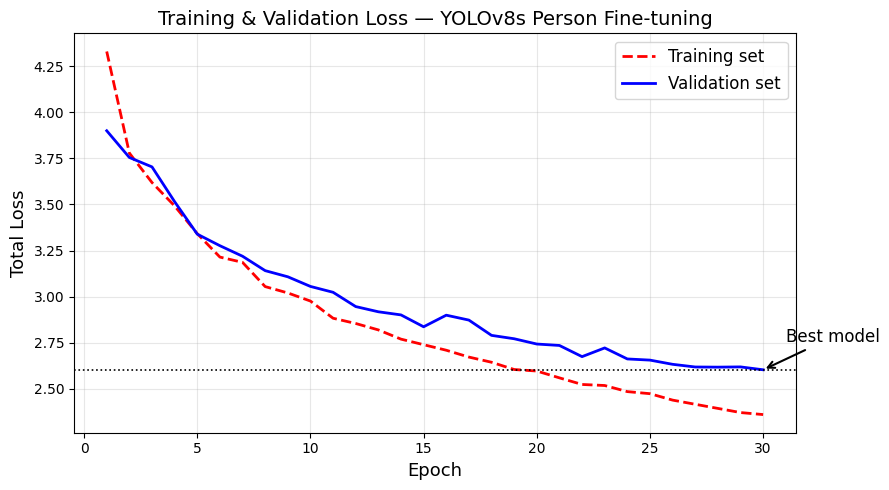

Saved: /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/plots/person_loss_curves.png


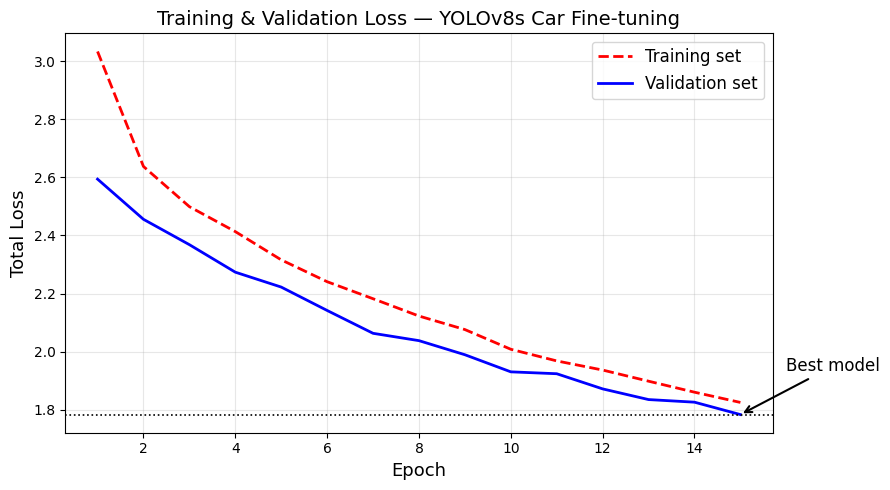

Saved: /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/plots/car_loss_curves.png


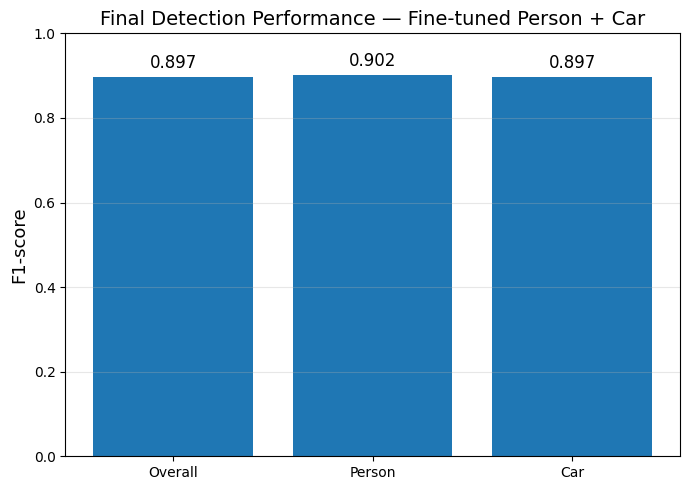

Saved: /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/plots/final_f1_scores.png


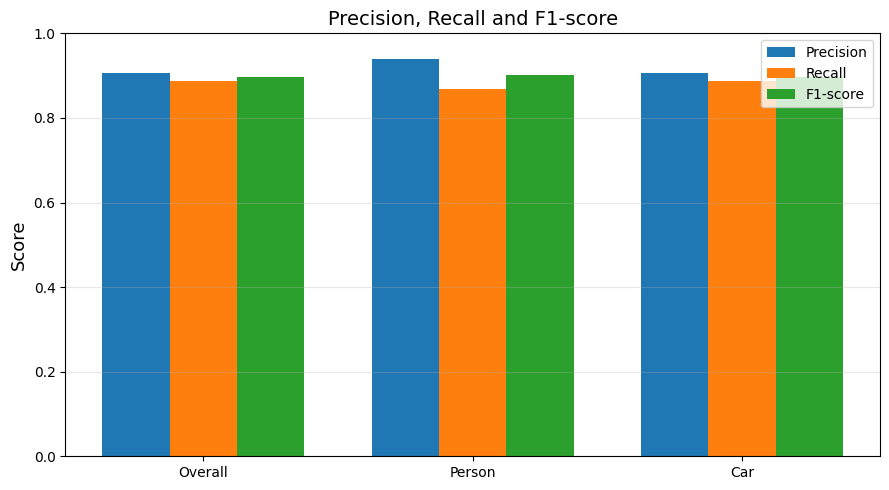

Saved: /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/plots/precision_recall_f1.png


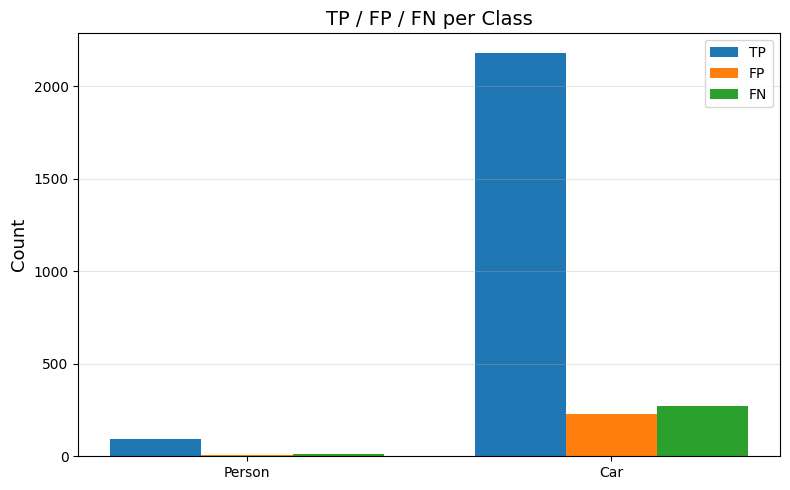

Saved: /content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/plots/tp_fp_fn_per_class.png

All plots saved in:
/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/plots


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# PATHS
# =========================
PLOTS_DIR = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

PERSON_RESULTS_CSV = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/person_finetune/yolov8s_kitti_person_gpu/results.csv"
CAR_RESULTS_CSV = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI/car_finetune/yolov8s_kitti_car_gpu-20/results.csv"

COUNTS_CSV = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_car_finetuned/kitti_detection_counts.csv"
SUMMARY_CSV = "/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/KITTI_results_person_car_finetuned/kitti_detection_eval_summary.csv"

# =========================
# HELPER: Loss curves
# =========================
def plot_loss_curve(results_csv, title, save_name):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    epochs = df["epoch"]

    train_loss = df["train/box_loss"] + df["train/cls_loss"] + df["train/dfl_loss"]
    val_loss = df["val/box_loss"] + df["val/cls_loss"] + df["val/dfl_loss"]

    best_idx = val_loss.idxmin()
    best_epoch = epochs.iloc[best_idx]
    best_val = val_loss.iloc[best_idx]

    plt.figure(figsize=(9, 5))
    plt.plot(epochs, train_loss, "r--", linewidth=2, label="Training set")
    plt.plot(epochs, val_loss, "b-", linewidth=2, label="Validation set")
    plt.axhline(y=best_val, color="black", linestyle=":", linewidth=1.2)

    plt.annotate(
        "Best model",
        xy=(best_epoch, best_val),
        xytext=(best_epoch + 1, best_val + 0.15),
        fontsize=12,
        arrowprops=dict(arrowstyle="->", color="black", lw=1.5)
    )

    plt.xlabel("Epoch", fontsize=13)
    plt.ylabel("Total Loss", fontsize=13)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = os.path.join(PLOTS_DIR, save_name)
    plt.savefig(save_path, dpi=150)
    plt.show()

    print("Saved:", save_path)


# =========================
# 1. Person loss curve
# =========================
plot_loss_curve(
    PERSON_RESULTS_CSV,
    "Training & Validation Loss — YOLOv8s Person Fine-tuning",
    "person_loss_curves.png"
)

# =========================
# 2. Car loss curve
# =========================
plot_loss_curve(
    CAR_RESULTS_CSV,
    "Training & Validation Loss — YOLOv8s Car Fine-tuning",
    "car_loss_curves.png"
)

# =========================
# 3. Metrics from summary
# =========================
summary_df = pd.read_csv(SUMMARY_CSV)
row = summary_df.iloc[0]

overall_f1 = row["global_f1_score"]
person_f1 = row["global_f1_person"]
car_f1 = row["global_f1_car"]

overall_precision = row["global_precision"]
person_precision = row["global_precision_person"]
car_precision = row["global_precision_car"]

overall_recall = row["global_recall"]
person_recall = row["global_recall_person"]
car_recall = row["global_recall_car"]

tp_person = row["global_TP_person"]
fp_person = row["global_FP_person"]
fn_person = row["global_FN_person"]

tp_car = row["global_TP_car"]
fp_car = row["global_FP_car"]
fn_car = row["global_FN_car"]

# =========================
# 4. Final F1-score bar chart
# =========================
labels = ["Overall", "Person", "Car"]
f1_scores = [overall_f1, person_f1, car_f1]

plt.figure(figsize=(7, 5))
plt.bar(labels, f1_scores)
plt.ylim(0, 1)
plt.ylabel("F1-score", fontsize=13)
plt.title("Final Detection Performance — Fine-tuned Person + Car", fontsize=14)

for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=12)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

save_path = os.path.join(PLOTS_DIR, "final_f1_scores.png")
plt.savefig(save_path, dpi=150)
plt.show()
print("Saved:", save_path)

# =========================
# 5. Precision / Recall / F1 grouped bar chart
# =========================
classes = ["Overall", "Person", "Car"]
precision_values = [overall_precision, person_precision, car_precision]
recall_values = [overall_recall, person_recall, car_recall]
f1_values = [overall_f1, person_f1, car_f1]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, precision_values, width, label="Precision")
plt.bar(x, recall_values, width, label="Recall")
plt.bar(x + width, f1_values, width, label="F1-score")

plt.xticks(x, classes)
plt.ylim(0, 1)
plt.ylabel("Score", fontsize=13)
plt.title("Precision, Recall and F1-score", fontsize=14)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

save_path = os.path.join(PLOTS_DIR, "precision_recall_f1.png")
plt.savefig(save_path, dpi=150)
plt.show()
print("Saved:", save_path)

# =========================
# 6. TP / FP / FN per class
# =========================
classes = ["Person", "Car"]
tp = [tp_person, tp_car]
fp = [fp_person, fp_car]
fn = [fn_person, fn_car]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, tp, width, label="TP")
plt.bar(x, fp, width, label="FP")
plt.bar(x + width, fn, width, label="FN")

plt.xticks(x, classes)
plt.ylabel("Count", fontsize=13)
plt.title("TP / FP / FN per Class", fontsize=14)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

save_path = os.path.join(PLOTS_DIR, "tp_fp_fn_per_class.png")
plt.savefig(save_path, dpi=150)
plt.show()
print("Saved:", save_path)

print("\nAll plots saved in:")
print(PLOTS_DIR)